In [1]:
import sys; sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/credit_default_features.csv")
y = df["default"]
X = df.drop(columns=["default"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

lgbm = joblib.load("../src/lgbm_model.joblib")

In [2]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

# For binary classification, LightGBM's TreeExplainer sometimes returns
# a list [class_0_values, class_1_values] and sometimes a single array
# depending on version — handle both cases.
if isinstance(shap_values, list):
    shap_values_default = shap_values[1]
else:
    shap_values_default = shap_values

print(shap_values_default.shape)

(5993, 40)


C:\Users\Lenovo\credit-risk-pd-ecl\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


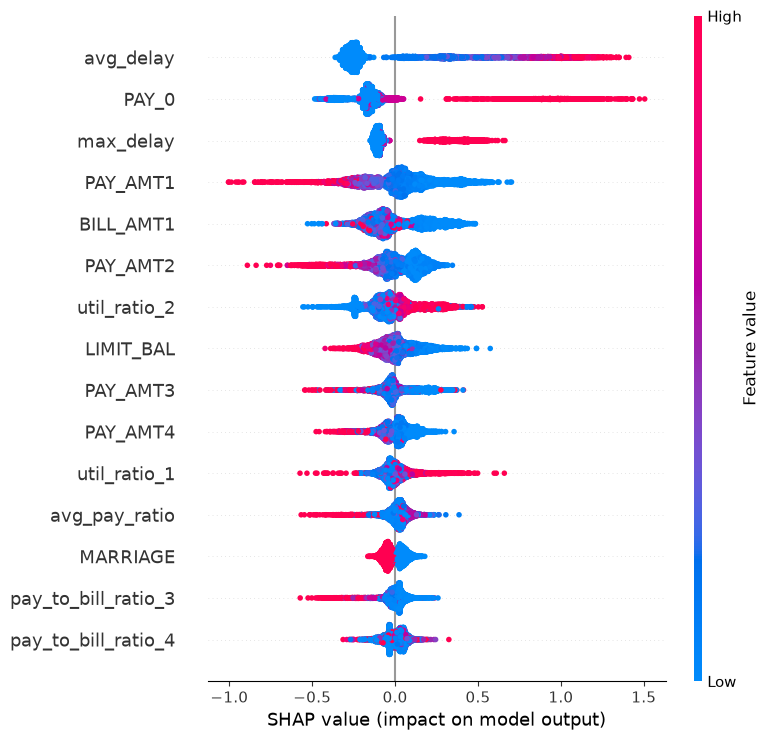

In [3]:
plt.figure()
shap.summary_plot(shap_values_default, X_test, show=False, max_display=15)
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

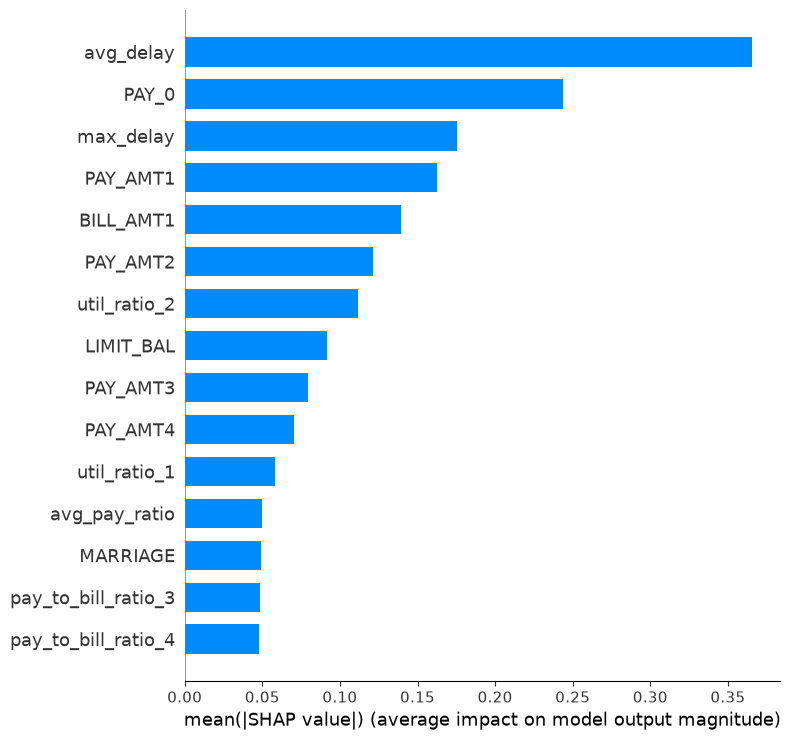

In [4]:
plt.figure()
shap.summary_plot(shap_values_default, X_test, plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.savefig("../reports/figures/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

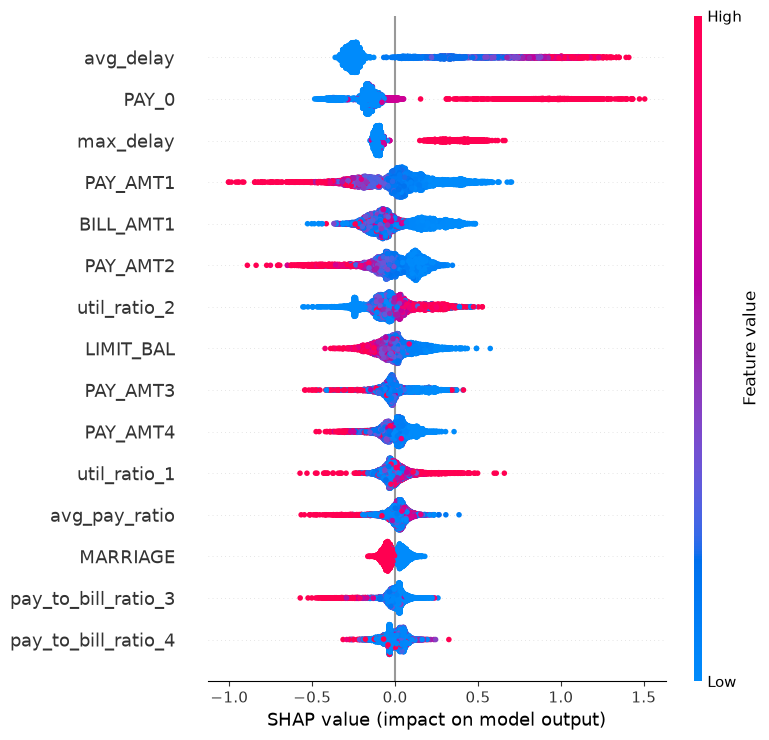

In [5]:
shap.summary_plot(shap_values_default, X_test, max_display=15)

In [ ]:
plt.figure()
shap.summary_plot(shap_values_default, X_test, show=False, max_display=15)
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()

plt.figure()
shap.summary_plot(shap_values_default, X_test, plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.savefig("../reports/figures/shap_bar.png", dpi=150, bbox_inches="tight")
plt.close()